# Episodic TF enrichment: knockout programs

IRF4 KO (Z4) and BLIMP1 KO (Z5) cellular programs enriched against the episodic GRNs of the GC branch:
`trajectory_range=(1, 3)`, `num_points=40`, 8 episodes of 5 points, 98th-percentile edge selection
(direct-effect network `w`, edge filter p < 1e-3, HLA- genes dropped from the programs).
Tables come from `config.IRF4["ep1".."ep8"]` and `config.BLIMP1[...]` in `../datasets.yaml`.

## Provenance

The tables are produced by `run_episodic_enrichment_bcell.py --programs ko` (this folder), the same
pipeline as the Fig3_2 PB/GC tables (`TemporalManager.enrich_episode`), on the fixed `focal.temporal`
code: regulator expression is taken from each episode's own 5-point window and matched to edges by TF
name (`focal` ISSUES #3 and #1). The Oct 2025 tables the groups pointed at before were computed
before those fixes -- every episode after the first was scaled by episode-1 regulator expression, and
most edges by another TF's expression -- and are kept only for provenance in
`legacy_oct2025_prefix_bug/` next to the new ones. Run settings, log and the 8 episodic GRNs
(`episodic_grn_edges/episode_{i}_gc.parquet`) are in `{inputs}/ko_gc_98_run/`.


In [1]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
from focal.io import DatasetPaths

# DatasetPaths.find() walks up from the kernel's working directory to the first
# datasets.yaml (or uses $FOCAL_DATASETS), so it works wherever Jupyter was started.
config = DatasetPaths.find()


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [3]:
from focal.temporal import *      # classes AND their figures

# Episodic enrichment plots

Dotplots use p < 0.08. The dotplot's default requirement of >= 2 LF targets and >= 2 downstream targets per TF leaves only 4 (IRF4 KO: IKZF2, MBD2, RBPJ, TCF12) and 3 (BLIMP1 KO: BPTF, IKZF2, RBPJ) TFs at p < 0.05 on the regenerated tables, so the cutoff is relaxed to 0.08 here (6 and 8 TFs).


In [4]:
dfs_irf4_ko   = [pd.read_csv(config.IRF4[f'ep{i}'])   for i in range(1, len(config.IRF4) + 1)]
dfs_blimp1_ko = [pd.read_csv(config.BLIMP1[f'ep{i}']) for i in range(1, len(config.BLIMP1) + 1)]
ko_episode_labels = [f'Ep{i}' for i in range(1, len(dfs_irf4_ko) + 1)]

# Dotplot PDFs go to Fig5_results/p_<cutoff>/ next to this notebook (git-ignored, like Fig4_2_results)
RESULTS_ROOT = os.path.join(os.getcwd(), 'Fig5_results')
RESULTS_DIR_008 = os.path.join(RESULTS_ROOT, 'p_0.08')
os.makedirs(RESULTS_DIR_008, exist_ok=True)


Filtered to 25 TFs that meet gene count criteria
Further filtered to 6 TFs that meet significance threshold < 0.08


/ocean/projects/cis240075p/asachan/methods/focal_codebases/focal/src/focal/temporal/_episodes.py:957: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


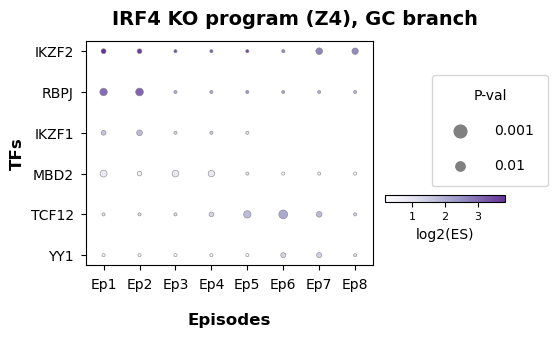

In [5]:
fig, plot_data, plotted_tfs_irf4_ko = plot_tf_episodic_enrichment_dotplot(
    dfs=dfs_irf4_ko,
    episode_labels=ko_episode_labels,
    figsize=(6, 3.5), #breadth by length
    p_value_threshold=0.08,
    min_significance_threshold=0.08,
    min_dot_size=10,
    max_dot_size=200,
    cmap_name="Purples",
    tf_order=None,
    figure_title="IRF4 KO program (Z4), GC branch",
    log_scale=True,
    horizontal_layout=False
)
fig.savefig(os.path.join(RESULTS_DIR_008, "z4_irf4_ko_gc_ee_008.pdf"), dpi=300, bbox_inches="tight")

Filtered to 28 TFs that meet gene count criteria
Further filtered to 8 TFs that meet significance threshold < 0.08


/ocean/projects/cis240075p/asachan/methods/focal_codebases/focal/src/focal/temporal/_episodes.py:957: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


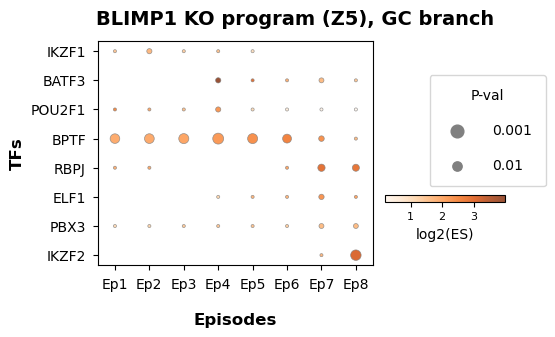

In [6]:
fig, plot_data, plotted_tfs_blimp1_ko = plot_tf_episodic_enrichment_dotplot(
    dfs=dfs_blimp1_ko,
    episode_labels=ko_episode_labels,
    figsize=(6, 3.5), #breadth by length
    p_value_threshold=0.08,
    min_significance_threshold=0.08,
    min_dot_size=10,
    max_dot_size=200,
    cmap_name="Oranges",
    tf_order=None,
    figure_title="BLIMP1 KO program (Z5), GC branch",
    log_scale=True,
    horizontal_layout=False
)
fig.savefig(os.path.join(RESULTS_DIR_008, "z5_blimp1_ko_gc_ee_008.pdf"), dpi=300, bbox_inches="tight")

# Strict cutoff: p < 0.05

Same tables and the same >= 2 LF-target / >= 2 downstream-target rule, at the dotplot's default
p < 0.05. PDFs go to `Fig5_results/p_0.05/` (the p < 0.08 plots above are in `Fig5_results/p_0.08/`).
The last cell lists which TFs drop out relative to the p < 0.08 plots above.

In [7]:
RESULTS_DIR = os.path.join(RESULTS_ROOT, 'p_0.05')
os.makedirs(RESULTS_DIR, exist_ok=True)
print(RESULTS_DIR)

/ocean/projects/cis240075p/asachan/methods/focal_codebases/focal_notebooks/temporal/analysis/Fig5_results/p_0.05


Filtered to 25 TFs that meet gene count criteria
Further filtered to 4 TFs that meet significance threshold < 0.05


/ocean/projects/cis240075p/asachan/methods/focal_codebases/focal/src/focal/temporal/_episodes.py:957: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


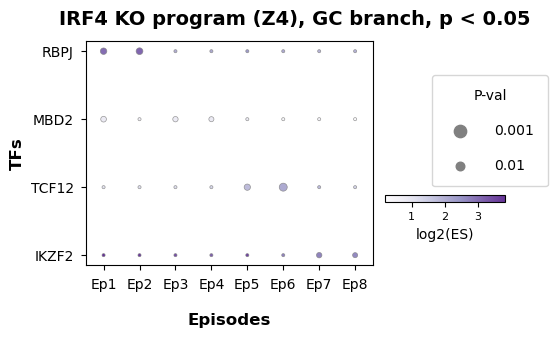

In [8]:
fig, plot_data_irf4_005, plotted_tfs_irf4_ko_005 = plot_tf_episodic_enrichment_dotplot(
    dfs=dfs_irf4_ko,
    episode_labels=ko_episode_labels,
    figsize=(6, 3.5),
    p_value_threshold=0.05,
    min_significance_threshold=0.05,
    min_dot_size=10,
    max_dot_size=200,
    cmap_name="Purples",
    tf_order=None,
    figure_title="IRF4 KO program (Z4), GC branch, p < 0.05",
    log_scale=True,
    horizontal_layout=False
)
fig.savefig(os.path.join(RESULTS_DIR, "z4_irf4_ko_gc_ee_005.pdf"), dpi=300, bbox_inches="tight")

Filtered to 28 TFs that meet gene count criteria
Further filtered to 3 TFs that meet significance threshold < 0.05


/ocean/projects/cis240075p/asachan/methods/focal_codebases/focal/src/focal/temporal/_episodes.py:957: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


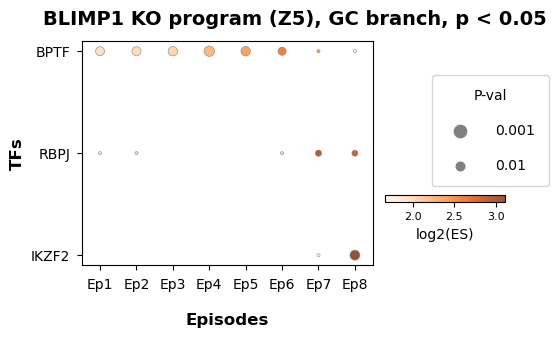

In [9]:
fig, plot_data_blimp1_005, plotted_tfs_blimp1_ko_005 = plot_tf_episodic_enrichment_dotplot(
    dfs=dfs_blimp1_ko,
    episode_labels=ko_episode_labels,
    figsize=(6, 3.5),
    p_value_threshold=0.05,
    min_significance_threshold=0.05,
    min_dot_size=10,
    max_dot_size=200,
    cmap_name="Oranges",
    tf_order=None,
    figure_title="BLIMP1 KO program (Z5), GC branch, p < 0.05",
    log_scale=True,
    horizontal_layout=False
)
fig.savefig(os.path.join(RESULTS_DIR, "z5_blimp1_ko_gc_ee_005.pdf"), dpi=300, bbox_inches="tight")

In [10]:
# Which TFs survive the stricter cutoff, and in which episodes they are significant
for name, tfs_008, tfs_005, dfs in [
    ("IRF4 KO",   plotted_tfs_irf4_ko,   plotted_tfs_irf4_ko_005,   dfs_irf4_ko),
    ("BLIMP1 KO", plotted_tfs_blimp1_ko, plotted_tfs_blimp1_ko_005, dfs_blimp1_ko),
]:
    tfs_008, tfs_005 = list(tfs_008), list(tfs_005)
    print(f"{name}: p<0.08 -> {len(tfs_008)} TFs {tfs_008}")
    print(f"{name}: p<0.05 -> {len(tfs_005)} TFs {tfs_005}")
    print(f"{name}: dropped at 0.05 -> {sorted(set(tfs_008) - set(tfs_005))}")
    for tf in tfs_005:
        eps = [lab for lab, df in zip(ko_episode_labels, dfs)
               if (df.TF == tf).any() and df.loc[df.TF == tf, 'p_value'].iloc[0] < 0.05]
        print(f"    {tf}: significant in {eps}")
    print()

IRF4 KO: p<0.08 -> 6 TFs ['IKZF2', 'RBPJ', 'IKZF1', 'MBD2', 'TCF12', 'YY1']
IRF4 KO: p<0.05 -> 4 TFs ['RBPJ', 'MBD2', 'TCF12', 'IKZF2']
IRF4 KO: dropped at 0.05 -> ['IKZF1', 'YY1']
    RBPJ: significant in ['Ep1', 'Ep2']
    MBD2: significant in ['Ep1', 'Ep3', 'Ep4']
    TCF12: significant in ['Ep5', 'Ep6']
    IKZF2: significant in ['Ep7', 'Ep8']

BLIMP1 KO: p<0.08 -> 8 TFs ['IKZF1', 'BATF3', 'POU2F1', 'BPTF', 'RBPJ', 'ELF1', 'PBX3', 'IKZF2']
BLIMP1 KO: p<0.05 -> 3 TFs ['BPTF', 'RBPJ', 'IKZF2']
BLIMP1 KO: dropped at 0.05 -> ['BATF3', 'ELF1', 'IKZF1', 'PBX3', 'POU2F1']
    BPTF: significant in ['Ep1', 'Ep2', 'Ep3', 'Ep4', 'Ep5', 'Ep6']
    RBPJ: significant in ['Ep7', 'Ep8']
    IKZF2: significant in ['Ep8']

